In [15]:
import os

import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import matplotlib.pyplot as plt

load_dotenv()

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

In [45]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
DB_HOST = os.getenv("DB_HOST", "127.0.0.1")
DB_PORT = int(os.getenv("DB_PORT", "3306"))
DB_USER = os.getenv("DB_USER", "root")
DB_PASSWORD = os.getenv("DB_PASSWORD", "")
DB_NAME = "fintech_fraud_lab_class"

In [3]:
db_url = URL.create(
    "mysql+pymysql",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
    query={"charset": "utf8mb4"}
)

engine = create_engine(db_url, pool_pre_ping=True)

In [4]:
q = """
SELECT *
FROM bureau_reports
"""
bureau_df = pd.read_sql(q, engine)
print(bureau_df.shape)
print(bureau_df.head())
print(bureau_df.info())

(840000, 11)
   report_id  customer_id report_date  external_credit_score  \
0          1            1  2021-08-01                    737   
1          2            1  2022-08-01                    737   
2          3            1  2023-08-01                    737   
3          4            1  2024-07-31                    737   
4          5            1  2025-07-31                    737   

   credit_card_count  loan_count  delinquency_30d_count  \
0                  4           1                      0   
1                  2           0                      0   
2                  1           0                      1   
3                  3           0                      0   
4                  4           1                      0   

   delinquency_90d_count  inquiries_6m  revolving_balance  utilization_rate  
0                      0             2         679,714.24              0.21  
1                      0             3         249,390.60              0.14  
2            

In [21]:
table_name = 'loan_applications'

q = """
SELECT *
FROM loan_applications
"""
df = pd.read_sql(q, engine)

In [24]:
loan_df = df[df["approved"]==1].copy()

In [7]:
bureau_df['report_date'] = pd.to_datetime(bureau_df["report_date"], errors="coerce")
print(bureau_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 840000 entries, 0 to 839999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   report_id              840000 non-null  int64        
 1   customer_id            840000 non-null  int64        
 2   report_date            840000 non-null  datetime64[s]
 3   external_credit_score  840000 non-null  int64        
 4   credit_card_count      840000 non-null  int64        
 5   loan_count             840000 non-null  int64        
 6   delinquency_30d_count  840000 non-null  int64        
 7   delinquency_90d_count  840000 non-null  int64        
 8   inquiries_6m           840000 non-null  int64        
 9   revolving_balance      840000 non-null  float64      
 10  utilization_rate       840000 non-null  float64      
dtypes: datetime64[s](1), float64(2), int64(8)
memory usage: 70.5 MB
None


In [8]:
bureau_df.head(5)

,report_id,customer_id,report_date,external_credit_score,credit_card_count,loan_count,delinquency_30d_count,delinquency_90d_count,inquiries_6m,revolving_balance,utilization_rate
0,1,1,2021-08-01,737,4,1,0,0,2,"679,714.24",0.21
1,2,1,2022-08-01,737,2,0,0,0,3,"249,390.60",0.14
2,3,1,2023-08-01,737,1,0,1,0,0,"1,126,100.68",0.40
3,4,1,2024-07-31,737,3,0,0,0,1,"2,140,371.69",0.04
4,5,1,2025-07-31,737,4,1,0,0,0,"641,572.41",0.41


In [9]:
bureau_summary = pd.DataFrame({
    "dtype": bureau_df.dtypes,
    "non_null_count": bureau_df.notna().sum(),
    "null_count": bureau_df.isna().sum(),
    "null_rate": bureau_df.isna().mean(),
    "nunique": bureau_df.nunique()
})

bureau_summary

,dtype,non_null_count,null_count,null_rate,nunique
report_id,int64,840000,0,0.00,840000
customer_id,int64,840000,0,0.00,120000
report_date,datetime64[s],840000,0,0.00,7
external_credit_score,int64,840000,0,0.00,572
credit_card_count,int64,840000,0,0.00,11
loan_count,int64,840000,0,0.00,7
delinquency_30d_count,int64,840000,0,0.00,6
delinquency_90d_count,int64,840000,0,0.00,5
inquiries_6m,int64,840000,0,0.00,16
revolving_balance,float64,840000,0,0.00,838381


In [10]:
print("전체 행 수:", len(bureau_df))
print("고유 report_id 수:", bureau_df["report_id"].nunique())
print("고유 customer_id 수:", bureau_df["customer_id"].nunique())
print("report_id 중복 수:", bureau_df["report_id"].duplicated().sum())

전체 행 수: 840000
고유 report_id 수: 840000
고유 customer_id 수: 120000
report_id 중복 수: 0


In [13]:
reports_per_customer = (
    bureau_df.groupby("customer_id")
    .size()
    .describe()
)

reports_per_customer

count   120,000.00
mean          7.00
std           0.00
min           7.00
25%           7.00
50%           7.00
75%           7.00
max           7.00
dtype: float64

In [19]:
bureau_df.duplicated(
    subset=["customer_id", "report_date"]
).sum()

np.int64(0)

In [20]:
report_date_summary = (
    bureau_df.groupby("report_date")
    .agg(
        report_count=("report_id", "count"),
        customer_count=("customer_id", "nunique")
    )
    .reset_index()
)

report_date_summary

,report_date,report_count,customer_count
0,2021-08-01,120000,120000
1,2022-08-01,120000,120000
2,2023-08-01,120000,120000
3,2024-07-31,120000,120000
4,2025-07-31,120000,120000
5,2026-02-01,120000,120000
6,2026-07-01,120000,120000


### 대출 신청일 이전 최신 보고서 선택

In [25]:
bureau_candidates = loan_df[
    ["application_id", "customer_id", "application_at"]
].merge(
    bureau_df,
    on="customer_id",
    how="left"
)

bureau_candidates["days_before_application"] = (
    bureau_candidates["application_at"].dt.normalize()
    - bureau_candidates["report_date"]
).dt.days

In [26]:
valid_bureau = bureau_candidates[
    bureau_candidates["days_before_application"] >= 0
].copy()

In [27]:
latest_bureau = (
    valid_bureau
    .sort_values(
        ["application_id", "report_date", "report_id"]
    )
    .drop_duplicates(
        subset="application_id",
        keep="last"
    )
)

In [29]:
print("승인 신청 수:", loan_df["application_id"].nunique())
print("최신 보고서가 연결된 신청 수:",
      latest_bureau["application_id"].nunique())
print("신청별 중복 수:",
      latest_bureau["application_id"].duplicated().sum())
print("미래 보고서 수:",
      (latest_bureau["report_date"]
       > latest_bureau["application_at"].dt.normalize()).sum())

승인 신청 수: 137094
최신 보고서가 연결된 신청 수: 137094
신청별 중복 수: 0
미래 보고서 수: 0


In [30]:
selected_report_summary = (
    latest_bureau.groupby("report_date")
    .agg(
        application_count=("application_id", "count"),
        customer_count=("customer_id", "nunique")
    )
    .reset_index()
)

selected_report_summary

,report_date,application_count,customer_count
0,2021-08-01,34419,29531
1,2022-08-01,34290,29514
2,2023-08-01,34135,29266
3,2024-07-31,34159,29362
4,2025-07-31,91,91


In [31]:
latest_bureau["days_before_application"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
)

count   137,094.00
mean        181.96
std         105.55
min           0.00
25%          90.00
50%         182.00
75%         273.00
90%         328.00
95%         346.00
99%         361.00
max         364.00
Name: days_before_application, dtype: float64

In [32]:
latest_bureau["report_age_group"] = pd.cut(
    latest_bureau["days_before_application"],
    bins=[-1, 30, 90, 180, 365, float("inf")],
    labels=[
        "30일 이내",
        "31~90일",
        "91~180일",
        "181~365일",
        "365일 초과"
    ]
)

report_age_summary = (
    latest_bureau["report_age_group"]
    .value_counts(sort=False)
    .rename_axis("report_age_group")
    .reset_index(name="application_count")
)

report_age_summary["ratio"] = (
    report_age_summary["application_count"]
    / len(latest_bureau)
    * 100
).round(2)

report_age_summary

,report_age_group,application_count,ratio
0,30일 이내,11829,8.63
1,31~90일,22481,16.40
2,91~180일,33614,24.52
3,181~365일,69170,50.45
4,365일 초과,0,0.00


In [33]:
loan_df["application_at"].agg(["min", "max"])

min   2021-08-01 00:02:53
max   2025-07-31 23:52:37
Name: application_at, dtype: datetime64[us]

In [34]:
latest_bureau["bureau_report_age_days"] = (
    latest_bureau["days_before_application"]
)

In [36]:
bureau_df.columns

Index(['report_id', 'customer_id', 'report_date', 'external_credit_score',
       'credit_card_count', 'loan_count', 'delinquency_30d_count',
       'delinquency_90d_count', 'inquiries_6m', 'revolving_balance',
       'utilization_rate'],
      dtype='str')

In [37]:
bureau_features = [
    "external_credit_score",
    "credit_card_count",
    "loan_count",
    "delinquency_30d_count",
    "delinquency_90d_count",
    "inquiries_6m",
    "revolving_balance",
    "utilization_rate"
]

latest_bureau[bureau_features].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
external_credit_score,"137,094.00",726.80,88.60,381.00,529.00,665.00,726.00,788.00,875.00,932.00,950.00
credit_card_count,"137,094.00",2.53,1.47,0.00,0.00,1.00,2.00,4.00,5.00,6.00,9.00
loan_count,"137,094.00",0.91,0.88,0.00,0.00,0.00,1.00,1.00,2.00,3.00,5.00
delinquency_30d_count,"137,094.00",0.09,0.31,0.00,0.00,0.00,0.00,0.00,1.00,1.00,4.00
delinquency_90d_count,"137,094.00",0.02,0.15,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00
inquiries_6m,"137,094.00",1.49,1.47,0.00,0.00,0.00,1.00,2.00,4.00,7.00,15.00
revolving_balance,"137,094.00","1,200,869.86","1,823,503.77","6,095.93","62,746.45","330,967.52","667,362.25","1,364,453.90","3,965,538.54","8,329,211.91","136,605,563.09"
utilization_rate,"137,094.00",0.31,0.18,0.00,0.03,0.18,0.29,0.43,0.64,0.80,1.20


In [38]:
utilization_over_100 = (
    latest_bureau["utilization_rate"] > 1
).sum()

utilization_over_100_ratio = (
    latest_bureau["utilization_rate"].gt(1).mean() * 100
)

print("100% 초과 건수:", utilization_over_100)
print("100% 초과 비율:", round(utilization_over_100_ratio, 2), "%")

100% 초과 건수: 65
100% 초과 비율: 0.05 %


In [39]:
(
    latest_bureau["delinquency_90d_count"]
    > latest_bureau["delinquency_30d_count"]
).sum()

np.int64(2457)

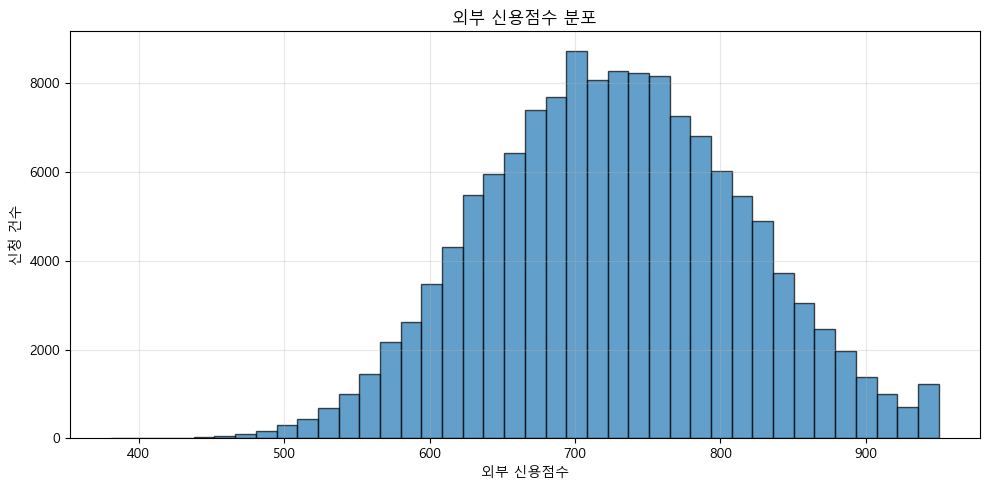

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(
    latest_bureau["external_credit_score"],
    bins=40,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("외부 신용점수")
plt.ylabel("신청 건수")
plt.title("외부 신용점수 분포")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "external_credit_score.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

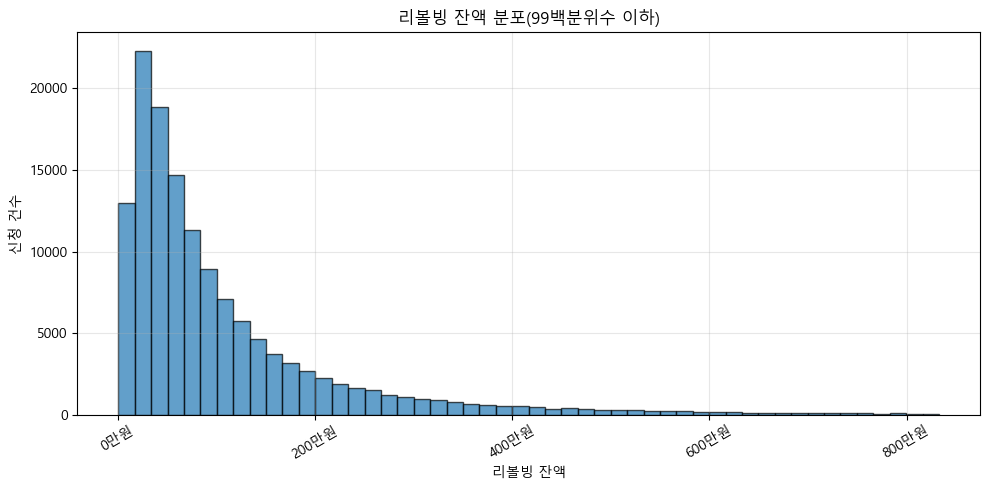

In [47]:
upper_99 = latest_bureau["revolving_balance"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    latest_bureau.loc[
        latest_bureau["revolving_balance"] <= upper_99,
        "revolving_balance"
    ],
    bins=50,
    edgecolor="black",
    alpha=0.7
)

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 10_000:,.0f}만원")
)

plt.xlabel("리볼빙 잔액")
plt.ylabel("신청 건수")
plt.title("리볼빙 잔액 분포(99백분위수 이하)")
plt.xticks(rotation=30)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "revolving_balance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [48]:
print("950점 건수:",
      latest_bureau["external_credit_score"].eq(950).sum())

print(
    latest_bureau["external_credit_score"]
    .value_counts()
    .sort_index(ascending=False)
    .head(10)
)

950점 건수: 768
external_credit_score
950    768
949     28
948     14
947     37
946     22
945     48
944     27
943     31
942     23
941     44
Name: count, dtype: int64


In [49]:
import numpy as np

latest_bureau["log_revolving_balance"] = np.log1p(
    latest_bureau["revolving_balance"]
)

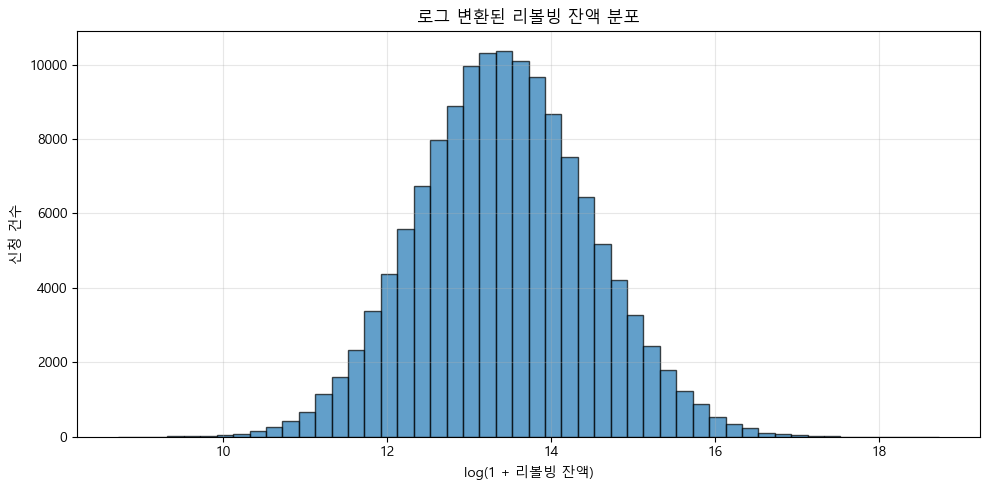

In [55]:
log_balance = np.log1p(
    latest_bureau["revolving_balance"]
)

plt.figure(figsize=(10, 5))

plt.hist(
    log_balance,
    bins=50,
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("log(1 + 리볼빙 잔액)")
plt.ylabel("신청 건수")
plt.title("로그 변환된 리볼빙 잔액 분포")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "images/log_revolving_balance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 유효성 검증

In [56]:
quality_checks = {
    "신용점수 범위 밖": (
        ~latest_bureau["external_credit_score"].between(0, 1000)
    ).sum(),

    "카드 수 음수": (
        latest_bureau["credit_card_count"] < 0
    ).sum(),

    "대출 수 음수": (
        latest_bureau["loan_count"] < 0
    ).sum(),

    "리볼빙 잔액 음수": (
        latest_bureau["revolving_balance"] < 0
    ).sum(),

    "한도 사용률 음수": (
        latest_bureau["utilization_rate"] < 0
    ).sum(),

    "한도 사용률 100% 초과": (
        latest_bureau["utilization_rate"] > 1
    ).sum()
}

pd.Series(quality_checks)

신용점수 범위 밖          0
카드 수 음수            0
대출 수 음수            0
리볼빙 잔액 음수          0
한도 사용률 음수          0
한도 사용률 100% 초과    65
dtype: int64

In [ ]:
bureau_features = [
    "external_credit_score",
    "credit_card_count",
    "loan_count",
    "delinquency_30d_count",
    "delinquency_90d_count",
    "inquiries_6m",
    "revolving_balance",
    "utilization_rate"
]

target_summary = (
    latest_bureau.groupby("default_12m_label")[bureau_features]
    .agg(["mean", "median"])
    .T
)

target_summary

In [58]:
latest_bureau.head()

,application_id,customer_id,application_at,report_id,report_date,external_credit_score,credit_card_count,loan_count,delinquency_30d_count,delinquency_90d_count,inquiries_6m,revolving_balance,utilization_rate,days_before_application,report_age_group,bureau_report_age_days,log_revolving_balance
0,3,14209,2022-04-11 20:26:48,99457,2021-08-01,856,2,1,2,0,2,"4,184,716.08",0.70,253,181~365일,253,15.25
7,6,87592,2022-02-03 13:35:13,613138,2021-08-01,738,3,1,0,0,0,"2,331,822.87",0.33,186,181~365일,186,14.66
15,7,11831,2023-05-25 19:52:05,82812,2022-08-01,556,3,0,1,0,1,"1,950,061.13",0.74,297,181~365일,297,14.48
22,8,113026,2023-07-17 17:29:51,791177,2022-08-01,734,1,0,0,0,5,"2,669,934.13",0.43,350,181~365일,350,14.80
30,9,66510,2024-03-25 19:11:38,465566,2023-08-01,725,0,3,0,0,2,"1,533,948.47",0.39,237,181~365일,237,14.24


In [60]:
bureau_feature_cols = [
    "application_id",
    "report_id",
    "report_date",
    "external_credit_score",
    "credit_card_count",
    "loan_count",
    "delinquency_30d_count",
    "delinquency_90d_count",
    "inquiries_6m",
    "revolving_balance",
    "utilization_rate",
    "days_before_application"
]

bureau_model_df = loan_df.merge(
    latest_bureau[bureau_feature_cols],
    on="application_id",
    how="left",
    validate="one_to_one"
)

In [62]:
print("model_df 행 수:", len(loan_df))
print("결합 후 행 수:", len(bureau_model_df))

print(
    "application_id 중복:",
    bureau_model_df["application_id"].duplicated().sum()
)

print(
    "신용보고서 미연결:",
    bureau_model_df["report_id"].isna().sum()
)

print(
    "Target 결측:",
    bureau_model_df["default_12m_label"].isna().sum()
)

model_df 행 수: 137094
결합 후 행 수: 137094
application_id 중복: 0
신용보고서 미연결: 0
Target 결측: 0


In [63]:
bureau_model_df.head(5)

,application_id,customer_id,application_at,product_type,requested_amount,approved_amount,loan_purpose,annual_income,employment_years,debt_to_income,bureau_score,internal_css_score,approved,interest_rate,default_12m_label,report_id,report_date,external_credit_score,credit_card_count,loan_count,delinquency_30d_count,delinquency_90d_count,inquiries_6m,revolving_balance,utilization_rate,days_before_application
0,3,14209,2022-04-11 20:26:48,CREDIT_LINE,"6,135,788.89","5,616,641.66",의료,"124,622,785.66",13.96,0.03,794,821.61,1,6.26,0.00,99457,2021-08-01,856,2,1,2,0,2,"4,184,716.08",0.70,253
1,6,87592,2022-02-03 13:35:13,MORTGAGE,"283,845,375.14","216,566,249.99",사업운영,"23,587,426.19",5.90,1.50,713,812.46,1,8.92,0.00,613138,2021-08-01,738,3,1,0,0,0,"2,331,822.87",0.33,186
2,7,11831,2023-05-25 19:52:05,CREDIT_LINE,"7,751,450.31","4,036,742.38",투자,"15,001,382.74",0.00,0.42,530,862.91,1,7.15,0.00,82812,2022-08-01,556,3,0,1,0,1,"1,950,061.13",0.74,297
3,8,113026,2023-07-17 17:29:51,PERSONAL_LOAN,"8,111,616.31","5,469,339.80",대환,"83,340,962.12",0.00,0.09,747,817.52,1,7.26,0.00,791177,2022-08-01,734,1,0,0,0,5,"2,669,934.13",0.43,350
4,9,66510,2024-03-25 19:11:38,AUTO_LOAN,"21,534,120.72","11,939,088.02",사업운영,"102,170,065.94",5.35,0.19,682,908.57,1,5.99,0.00,465566,2023-08-01,725,0,3,0,0,2,"1,533,948.47",0.39,237


In [64]:
bureau_features = [
    "external_credit_score",
    "credit_card_count",
    "loan_count",
    "delinquency_30d_count",
    "delinquency_90d_count",
    "inquiries_6m",
    "revolving_balance",
    "utilization_rate"
]

target_summary = (
    bureau_model_df
    .groupby("default_12m_label")[bureau_features]
    .agg(["mean", "median"])
    .T
)

target_summary

default_12m_label                    0.00         1.00
external_credit_score mean         728.02       698.05
                      median       727.00       695.00
credit_card_count     mean           2.53         2.52
                      median         2.00         2.00
loan_count            mean           0.91         0.91
                      median         1.00         1.00
delinquency_30d_count mean           0.08         0.15
                      median         0.00         0.00
delinquency_90d_count mean           0.02         0.05
                      median         0.00         0.00
inquiries_6m          mean           1.47         2.10
                      median         1.00         2.00
revolving_balance     mean   1,182,643.49 1,632,459.07
                      median   659,624.72   878,821.61
utilization_rate      mean           0.31         0.38
                      median         0.29         0.36

In [65]:
score_bins = [0, 600, 650, 700, 750, 800, 850, 1000]

bureau_model_df["credit_score_group"] = pd.cut(
    bureau_model_df["external_credit_score"],
    bins=score_bins,
    right=False
)

score_default_rate = (
    bureau_model_df.groupby(
        "credit_score_group",
        observed=True
    )
    .agg(
        application_count=("application_id", "count"),
        default_count=("default_12m_label", "sum"),
        default_rate=("default_12m_label", "mean")
    )
    .reset_index()
)

score_default_rate["default_rate"] *= 100
score_default_rate

,credit_score_group,application_count,default_count,default_rate
0,"[0, 600)",10204,779.00,7.63
1,"[600, 650)",17212,901.00,5.23
2,"[650, 700)",25802,"1,188.00",4.60
3,"[700, 750)",29246,"1,132.00",3.87
4,"[750, 800)",25331,835.00,3.30
5,"[800, 850)",17223,434.00,2.52
6,"[850, 1000)",12076,286.00,2.37


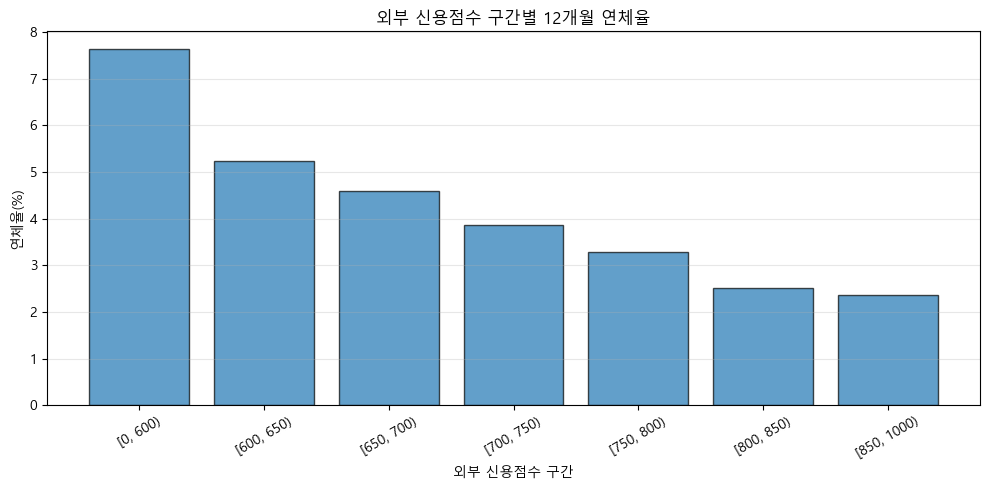

In [67]:
plt.figure(figsize=(10, 5))

plt.bar(
    score_default_rate["credit_score_group"].astype(str),
    score_default_rate["default_rate"],
    edgecolor="black",
    alpha=0.7
)

plt.xlabel("외부 신용점수 구간")
plt.ylabel("연체율(%)")
plt.title("외부 신용점수 구간별 12개월 연체율")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "images/external_credit_score.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 기존 연체 이력별 향후 연체율

In [68]:
bureau_model_df["has_30d_delinquency"] = (
    bureau_model_df["delinquency_30d_count"] > 0
).astype(int)

bureau_model_df["has_90d_delinquency"] = (
    bureau_model_df["delinquency_90d_count"] > 0
).astype(int)

In [69]:
delinquency_default_rate = (
    bureau_model_df.groupby("has_30d_delinquency")
    .agg(
        application_count=("application_id", "count"),
        default_count=("default_12m_label", "sum"),
        default_rate=("default_12m_label", "mean")
    )
)

delinquency_default_rate["default_rate"] *= 100
delinquency_default_rate

,application_count,default_count,default_rate
has_30d_delinquency,,,
0,126432,"4,822.00",3.81
1,10662,733.00,6.87


In [71]:
delinquency_default_rate = (
    bureau_model_df.groupby("has_90d_delinquency")
    .agg(
        application_count=("application_id", "count"),
        default_count=("default_12m_label", "sum"),
        default_rate_90=("default_12m_label", "mean")
    )
)

delinquency_default_rate["default_rate_90"] *= 100
delinquency_default_rate

,application_count,default_count,default_rate_90
has_90d_delinquency,,,
0,134095,"5,296.00",3.95
1,2999,259.00,8.64


In [72]:
pd.crosstab(
    bureau_model_df["has_30d_delinquency"],
    bureau_model_df["has_90d_delinquency"],
    margins=True
)

has_90d_delinquency,0,1,All
has_30d_delinquency,,,
0,124005,2427,126432
1,10090,572,10662
All,134095,2999,137094


In [75]:
bureau_model_df["delinquency_history_group"] = np.select(
    [
        (
            bureau_model_df["has_30d_delinquency"].eq(1)
            & bureau_model_df["has_90d_delinquency"].eq(1)
        ),
        (
            bureau_model_df["has_30d_delinquency"].eq(1)
            & bureau_model_df["has_90d_delinquency"].eq(0)
        ),
        (
            bureau_model_df["has_30d_delinquency"].eq(0)
            & bureau_model_df["has_90d_delinquency"].eq(1)
        )
    ],
    [
        "30일·90일 연체 모두 있음",
        "30일 연체만 있음",
        "90일 연체만 있음"
    ],
    default="연체 이력 없음"
)

In [76]:
group_order = [
    "연체 이력 없음",
    "30일 연체만 있음",
    "90일 연체만 있음",
    "30일·90일 연체 모두 있음"
]

bureau_model_df["delinquency_history_group"] = pd.Categorical(
    bureau_model_df["delinquency_history_group"],
    categories=group_order,
    ordered=True
)

delinquency_group_summary = (
    bureau_model_df.groupby(
        "delinquency_history_group",
        observed=True
    )
    .agg(
        application_count=("application_id", "count"),
        default_count=("default_12m_label", "sum"),
        default_rate=("default_12m_label", "mean")
    )
)

delinquency_group_summary["default_rate"] = (
    delinquency_group_summary["default_rate"] * 100
).round(2)

delinquency_group_summary

,application_count,default_count,default_rate
delinquency_history_group,,,
연체 이력 없음,124005,"4,634.00",3.74
30일 연체만 있음,10090,662.00,6.56
90일 연체만 있음,2427,188.00,7.75
30일·90일 연체 모두 있음,572,71.00,12.41


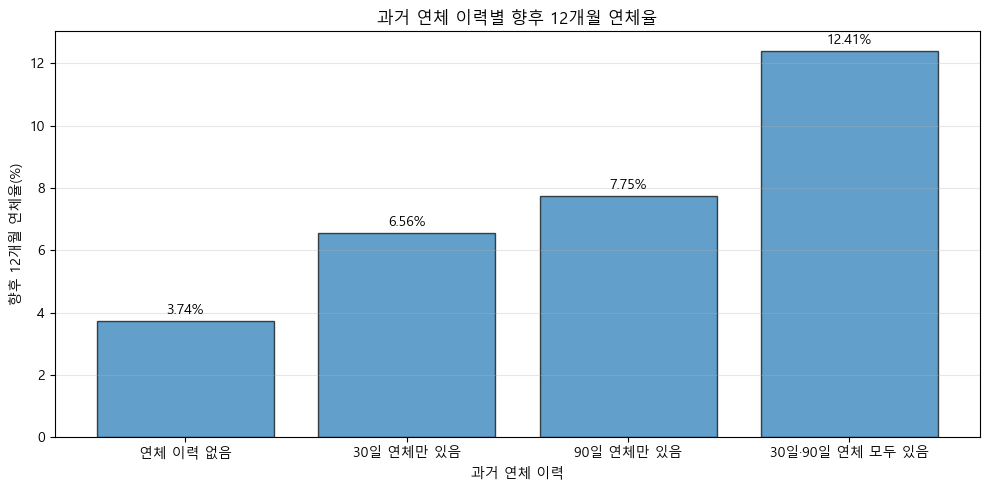

In [78]:
plot_df = delinquency_group_summary.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    plot_df["delinquency_history_group"].astype(str),
    plot_df["default_rate"],
    edgecolor="black",
    alpha=0.7
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in plot_df["default_rate"]
    ],
    padding=3
)

ax.set_xlabel("과거 연체 이력")
ax.set_ylabel("향후 12개월 연체율(%)")
ax.set_title("과거 연체 이력별 향후 12개월 연체율")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "images/delinquency_history_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [79]:
bureau_model_df["has_any_delinquency"] = (
    bureau_model_df["has_30d_delinquency"].eq(1)
    | bureau_model_df["has_90d_delinquency"].eq(1)
).astype(int)

bureau_model_df["has_both_delinquency"] = (
    bureau_model_df["has_30d_delinquency"].eq(1)
    & bureau_model_df["has_90d_delinquency"].eq(1)
).astype(int)

In [80]:
score_comparison = latest_bureau[
    ["application_id", "external_credit_score"]
].merge(
    loan_df[
        ["application_id", "bureau_score", "internal_css_score"]
    ],
    on="application_id",
    how="left"
)

score_comparison[
    [
        "external_credit_score",
        "bureau_score",
        "internal_css_score"
    ]
].corr()

,external_credit_score,bureau_score,internal_css_score
external_credit_score,1.00,0.82,0.20
bureau_score,0.82,1.00,0.20
internal_css_score,0.20,0.20,1.00


In [81]:
score_comparison[
    [
        "external_credit_score",
        "bureau_score",
        "internal_css_score"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
external_credit_score,"137,094.00",726.80,88.60,381.00,665.00,726.00,788.00,950.00
bureau_score,"137,094.00",727.99,89.14,384.00,664.00,726.00,790.00,950.00
internal_css_score,"137,094.00",874.48,41.29,701.45,853.24,879.55,902.11,999.00


In [82]:
score_comparison["bureau_external_score_gap"] = (
    score_comparison["bureau_score"]
    - score_comparison["external_credit_score"]
)

In [83]:
score_comparison["bureau_external_score_gap"].describe()

count   137,094.00
mean          1.19
std          52.64
min        -226.00
25%         -34.00
50%           1.00
75%          37.00
max         239.00
Name: bureau_external_score_gap, dtype: float64

In [84]:
score_bins = [0, 600, 650, 700, 750, 800, 850, 1000]

bureau_model_df["credit_score_group"] = pd.cut(
    bureau_model_df["external_credit_score"],
    bins=score_bins,
    right=False
)

score_default_rate = (
    bureau_model_df.groupby(
        "credit_score_group",
        observed=True
    )
    .agg(
        application_count=("application_id", "count"),
        default_count=("default_12m_label", "sum"),
        default_rate=("default_12m_label", "mean")
    )
    .reset_index()
)

score_default_rate["default_rate"] = (
    score_default_rate["default_rate"] * 100
).round(2)

score_default_rate

,credit_score_group,application_count,default_count,default_rate
0,"[0, 600)",10204,779.00,7.63
1,"[600, 650)",17212,901.00,5.23
2,"[650, 700)",25802,"1,188.00",4.60
3,"[700, 750)",29246,"1,132.00",3.87
4,"[750, 800)",25331,835.00,3.30
5,"[800, 850)",17223,434.00,2.52
6,"[850, 1000)",12076,286.00,2.37


In [85]:
bureau_model_df["inquiries_group"] = pd.cut(
    bureau_model_df["inquiries_6m"],
    bins=[-1, 0, 1, 2, 4, float("inf")],
    labels=["0회", "1회", "2회", "3~4회", "5회 이상"]
)

inquiries_default_rate = (
    bureau_model_df.groupby(
        "inquiries_group",
        observed=True
    )
    .agg(
        application_count=("application_id", "count"),
        default_count=("default_12m_label", "sum"),
        default_rate=("default_12m_label", "mean")
    )
    .reset_index()
)

inquiries_default_rate["default_rate"] = (
    inquiries_default_rate["default_rate"] * 100
).round(2)

inquiries_default_rate

,inquiries_group,application_count,default_count,default_rate
0,0회,36972,"1,108.00",3.00
1,1회,45228,"1,488.00",3.29
2,2회,28910,"1,142.00",3.95
3,3~4회,19879,"1,153.00",5.80
4,5회 이상,6105,664.00,10.88


In [87]:
bureau_model_df["utilization_group"] = pd.cut(
    bureau_model_df["utilization_rate"],
    bins=[
        -0.001,
        0.2,
        0.4,
        0.6,
        0.8,
        float("inf")
    ],
    labels=[
        "20% 이하",
        "20~40%",
        "40~60%",
        "60~80%",
        "80% 이상"
    ]
)

utilization_default_rate = (
    bureau_model_df.groupby(
        "utilization_group",
        observed=True
    )
    .agg(
        application_count=("application_id", "count"),
        default_count=("default_12m_label", "sum"),
        default_rate=("default_12m_label", "mean")
    )
    .reset_index()
)

utilization_default_rate["default_rate"] = (
    utilization_default_rate["default_rate"] * 100
).round(2)

utilization_default_rate

,utilization_group,application_count,default_count,default_rate
0,20% 이하,41851,"1,232.00",2.94
1,20~40%,54780,"1,973.00",3.60
2,40~60%,30418,"1,554.00",5.11
3,60~80%,8702,640.00,7.35
4,80% 이상,1343,156.00,11.62


In [88]:
bureau_model_df["revolving_balance_group"] = pd.cut(
    bureau_model_df["revolving_balance"],
    bins=[
        -float("inf"),
        500_000,
        1_000_000,
        2_000_000,
        5_000_000,
        float("inf")
    ],
    labels=[
        "50만원 이하",
        "50~100만원",
        "100~200만원",
        "200~500만원",
        "500만원 초과"
    ]
)

revolving_default_rate = (
    bureau_model_df.groupby(
        "revolving_balance_group",
        observed=True
    )
    .agg(
        application_count=("application_id", "count"),
        default_count=("default_12m_label", "sum"),
        default_rate=("default_12m_label", "mean")
    )
    .reset_index()
)

revolving_default_rate["default_rate"] = (
    revolving_default_rate["default_rate"] * 100
).round(2)

revolving_default_rate

,revolving_balance_group,application_count,default_count,default_rate
0,50만원 이하,53580,"1,711.00",3.19
1,50~100만원,35341,"1,341.00",3.79
2,100~200만원,27241,"1,218.00",4.47
3,200~500만원,16559,941.00,5.68
4,500만원 초과,4373,344.00,7.87
